# Begin

In [2]:
import os # @launchit.collect
import sys # @launchit.collect
import socket
import copy
from collections import namedtuple, defaultdict, Counter, deque # @launchit.collect
import random
import math
import datetime
import json # @launchit.collect
import pprint # @launchit.collect
import re 
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import pickle # @launchit.collect
import IPython 
from enum import StrEnum, auto # @launchit.collect
import multiprocessing as mp
import gzip
from functools import lru_cache
import piq

import lark # @launchit.collect

from tqdm.notebook import tqdm

import numpy as np # @launchit.collect
import cupy as cp
import einops
import pandas as pd
import matplotlib.pyplot as plt

import ale_py

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as VF
import torch.optim
import torch.multiprocessing as torch_mp
from torch.nn.attention import SDPBackend, sdpa_kernel

import optuna # @launchit.collect
from optuna.storages import JournalStorage # @launchit.collect
from optuna.storages.journal import JournalFileBackend # @launchit.collect
from optuna.trial import TrialState

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
build_project_root_path = '${BUILD_PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
sys.path.append(os.path.join(build_project_root_path, 'lib')) # @launchit.collect
from cleanrl.cleanrl_utils.atari_wrappers import (  # isort:skip
    ClipRewardEnv,
    EpisodicLifeEnv,
    FireResetEnv,
    MaxAndSkipEnv,
    NoopResetEnv,
)
import lang_utils as lu # @launchit.collect
import array_utils as au # @launchit.collect
from math_utils import RecursiveAverageFilter, RecursiveMovingAverageFilter
from logging_utils import *
from artifact_registry import * # @launchit.collect
from torch_utils import *
import launchit 
from hp_utils import * # @launchit.collect
from metrics_collector import RmqSummaryWriter, S3SummaryWriter
from autoincrement import Autoincrement

# Init

In [3]:
# @launchit.collect
class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    DOCKER_LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

In [4]:
# @launchit.collect_temp_config
# @launchit.disable

# Construct temporary CONFIG object for build and bootstrap purposes
if '${LAUNCHIT_FNAME}' != '$' + '{LAUNCHIT_FNAME}':
    notebook_fname = '${LAUNCHIT_FNAME}'
    notebook_basename = os.path.basename(notebook_fname)
    notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    subproject_name = os.path.basename(os.path.dirname(notebook_fname))
    
    if os.path.exists(os.path.join(project_root_path, '.docker_launch')):
        # This (bootstrap) config is for the very initial phase of docker launch when one needs to load hyperparameters.
        # This config will be recreated soon to full-fledged Config
        CONFIG = namedtuple('BootstrapConfig', 'initrd_path, exec_mode')(
            initrd_path=os.path.join(project_root_path, 'run', subproject_name, 'initrd-' + notebook_name),
            exec_mode=ExecMode.DOCKER_LAUNCH_NOTEBOOK,
        )
        assert Logging._instance is None, 'Must create Logging instance with use_raw_stdout=True, but Logging instance is already created'
        # use_raw_stdout is necessary because sys.stdout is hijacked by papermill and this will lead to problems
        # with string duplications written to stdout by child process (worker)
        # see https://share.google/aimode/ffIcoqyaJdgMsEcoW
        Logging.get(use_raw_stdout=True)    
    else:
        # Config to build docker launch
        CONFIG = namedtuple('BuildConfig', 
                            'initrd_path, relative_initrd_path, relative_run_path, relative_metrics_suite_fname, ' + 
                            'model_group_uri, self_fname, relative_self_fname, self_name, subproject_name, ' + 
                            'docker_registry, exec_mode, ' +
                            'artifact_registry_cache, artifact_registry')(
            initrd_path=os.path.join(build_project_root_path, 'run', subproject_name, 'initrd-' + notebook_name),
            relative_initrd_path=os.path.join('run', subproject_name, 'initrd-' + notebook_name), # relative to build project root
            relative_run_path=os.path.join('run', subproject_name),
            relative_metrics_suite_fname=os.path.join('run', subproject_name, notebook_name + '.metrics_suite.json'),
            model_group_uri='${MODEL_GROUP_URI}',
            self_fname=notebook_fname,
            relative_self_fname=lu.when('/run/' in notebook_fname, 'run/', '') + os.path.join(subproject_name, notebook_basename),  # relative to build project root
            self_name=notebook_name,
            subproject_name=subproject_name,
            docker_registry='cr.selcloud.ru/neurolab',
            exec_mode=ExecMode.LAUNCH_NOTEBOOK,
            artifact_registry_cache={}, 
            artifact_registry=None,
        )
        CONFIG = CONFIG._replace(artifact_registry=ArtifactRegistry(CONFIG.model_group_uri, cache=CONFIG.artifact_registry_cache))
        os.makedirs(CONFIG.initrd_path, exist_ok=True)

    Logging.get()(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n')
# @launchit.stop

In [5]:
def create_config():
    config = namedtuple('Config', 
                        'host_name, ' +
                        'project_root_path, project_root_uri, model_group_uri, subproject_path, data_path, private_data_path, run_path, initrd_path, ' + 
                        'self_fname, self_name, metrics_suite_fname, ' +
                        'subproject_name,' +
                        'is_cuda, cuda_device, docker_registry, exec_mode, is_interactive')(
        host_name=socket.gethostname(),
        project_root_path=project_root_path,
        project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
        model_group_uri=None,
        subproject_path=os.path.abspath('.'),
        data_path=os.path.join(project_root_path, 'data'),
        private_data_path=None,
        run_path=None,
        initrd_path=None,
        self_fname=None,
        self_name=None,
        metrics_suite_fname=None,
        subproject_name=None,
        is_cuda=torch.cuda.is_available(),
        cuda_device='cpu',
        docker_registry='cr.selcloud.ru/neurolab',
        exec_mode=ExecMode.MASTER_NOTEBOOK,
        is_interactive=True,
    )

    env_cuda_device = os.environ.get('CUDA_DEVICE')
    
    if torch.cuda.is_available():
        default_cuda_device = 'cuda'
        config = config._replace(cuda_device=lu.coalesce(env_cuda_device, default_cuda_device))
    else:
        assert env_cuda_device is None, f'CUDA device "{env_cuda_device}" is requested but CUDA is NOT available!'
    
    if IPython.get_ipython() is None:
        module_fname = __file__
        module_basename = os.path.basename(module_fname)
        module_name, _ = os.path.splitext(module_basename)
        
        config = config._replace(self_fname=module_fname, self_name=module_name)
        config = config._replace(exec_mode=ExecMode.LAUNCH_MODULE)
    else:
        with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
            notebook_fname = json.load(cf).get('jupyter_session')

            if notebook_fname is None:
                notebook_fname = os.path.join(config.subproject_path, os.path.basename('${LAUNCHIT_FNAME}'))
                assert os.path.exists(notebook_fname)
            
            notebook_basename = os.path.basename(notebook_fname)
            notebook_name, notebook_ext = os.path.splitext(notebook_basename)
        
            m = re.match(r'(\w+)-Copy\d+$', notebook_name)
        
            if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook
    
            config = config._replace(self_fname=notebook_fname, self_name=notebook_name)
            
            is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None

            if is_launch:
                if os.path.exists(os.path.join(project_root_path, '.docker_launch')):
                    config = config._replace(exec_mode=ExecMode.DOCKER_LAUNCH_NOTEBOOK)
                else:
                    config = config._replace(exec_mode=ExecMode.LAUNCH_NOTEBOOK)
            else:
                assert config.exec_mode == ExecMode.MASTER_NOTEBOOK
    
    config = config._replace(is_interactive=config.exec_mode in [ExecMode.MASTER_NOTEBOOK, ExecMode.LAUNCH_NOTEBOOK])
    config = config._replace(subproject_name=os.path.basename(os.path.dirname(config.self_fname)))
    config = config._replace(model_group_uri=f'{config.project_root_uri}.{config.subproject_name}')
    config = config._replace(run_path=os.path.join(project_root_path, 'run', config.subproject_name))
    config = config._replace(initrd_path=os.path.join(project_root_path, 'run', config.subproject_name, 'initrd-' + config.self_name))
    config = config._replace(private_data_path=os.path.join(config.data_path, config.subproject_name))
    config = config._replace(metrics_suite_fname=os.path.join(config.run_path, config.self_name + '.metrics_suite.json'))
    return config

In [6]:
# @launchit.disable_worker
au.init()
LOG = Logging.get()
RNG = np.random.default_rng()
CONFIG = create_config()
LOG.app_name = CONFIG.self_name
LOG.enable('syslog', CONFIG.exec_mode == ExecMode.LAUNCH_MODULE)
LOG.enable('stdout', CONFIG.exec_mode in [ExecMode.MASTER_NOTEBOOK, ExecMode.LAUNCH_NOTEBOOK])
LOG.enable('verbose_stdout', CONFIG.exec_mode == ExecMode.DOCKER_LAUNCH_NOTEBOOK)
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)
LOG(f'{os.environ=}', when=not CONFIG.is_interactive)
os.makedirs(CONFIG.private_data_path, exist_ok=True)
os.makedirs(CONFIG.run_path, exist_ok=True)
os.makedirs(CONFIG.initrd_path, exist_ok=True)

CONFIG=
{'host_name': 'thinkbook',
 'project_root_path': '/home/misha/dev/mine/neurolab',
 'project_root_uri': 'com.develorium.neurolab',
 'model_group_uri': 'com.develorium.neurolab.18_rl',
 'subproject_path': '/home/misha/dev/mine/neurolab/18_rl',
 'data_path': '/home/misha/dev/mine/neurolab/data',
 'private_data_path': '/home/misha/dev/mine/neurolab/data/18_rl',
 'run_path': '/home/misha/dev/mine/neurolab/run/18_rl',
 'initrd_path': '/home/misha/dev/mine/neurolab/run/18_rl/initrd-18b_explore_02',
 'self_fname': '/home/misha/dev/mine/neurolab/18_rl/18b_explore_02.ipynb',
 'self_name': '18b_explore_02',
 'metrics_suite_fname': '/home/misha/dev/mine/neurolab/run/18_rl/18b_explore_02.metrics_suite.json',
 'subproject_name': '18_rl',
 'is_cuda': False,
 'cuda_device': 'cpu',
 'docker_registry': 'cr.selcloud.ru/neurolab',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



In [16]:
ARTIFACT_REGISTRY = ArtifactRegistry(CONFIG.model_group_uri)

# Modules

In [11]:
dataset_notebook_fname = '18b_dataset_01.ipynb'
source_code = launchit.extract_source_code(dataset_notebook_fname, collect_inds=[None, 'export_dataset'])
DATSET_MODULE = lu.make_module(f'dataset_notebook', source_code)
DATSET_MODULE.CONFIG = CONFIG
DATSET_MODULE.RNG = RNG
DATSET_MODULE.LOG = LOG
sys.modules['__main__'].Dataset = DATSET_MODULE.Dataset # Req-d for unpickling

In [13]:
@lru_cache(maxsize=None)
def load_dataset(fname):
    with gzip.GzipFile(filename=fname, mode='rb') as gzip_file:
        dataset = pickle.load(gzip_file)
        return dataset

In [12]:
model_notebook_fname = '18b_world_model_02.ipynb'
source_code = launchit.extract_source_code(model_notebook_fname, collect_inds=[None, 'export'])
MODEL_MODULE = lu.make_module(f'model_notebook', source_code)
MODEL_MODULE.CONFIG = CONFIG
MODEL_MODULE.RNG = RNG
MODEL_MODULE.LOG = LOG

# Dataset

In [15]:
test_dataset_fname = os.path.join(CONFIG.private_data_path, 'test_dataset.2.pkl.gz')
TEST_DATASET = load_dataset(test_dataset_fname)

# Model

In [86]:
model_id = '18b_world_model_02:5'
coords = hp_parse_artifact_source(model_id)

model_params_data = ARTIFACT_REGISTRY.get_asset_content(coords.model_name, coords.model_version, asset_ext='json', asset_classifier='world_model_params', maven_group_id=coords.group_id)
model_params = MODEL_MODULE.WorldModel.Params(**json.loads(model_params_data.decode()))
model_params.ob_shape = tuple(model_params.ob_shape)
model_params.ob_grid_shape = tuple(model_params.ob_grid_shape)

if not CONFIG.is_cuda:
    model_params.attention_backend = 'MATH'

MODEL = MODEL_MODULE.WorldModel(model_params)
MODEL = MODEL.to(CONFIG.cuda_device)
MODEL = torch.compile(MODEL, fullgraph=True)

model_weights_data = ARTIFACT_REGISTRY.get_asset_content(coords.model_name, coords.model_version, asset_ext='pt', asset_classifier='world_model', maven_group_id=coords.group_id)

with io.BytesIO(model_weights_data) as b:
    kwargs = {}
    
    if not CONFIG.is_cuda:
        kwargs['map_location'] = torch.device('cpu')
        
    MODEL.load_state_dict(torch.load(b, **kwargs))

# Explore pixel logits, contents, gates, alpha-masks

In [89]:
TEST_DATASET.init_iteration(batch_size=1, is_shuffled=True)

with torch.no_grad():
    batch = next(iter(TEST_DATASET))
    batch_mask = batch.pmasks.sum(axis=1) < MODEL.params.sequence_length
    batch = batch._replace(
        pmasks=batch.pmasks[batch_mask],
        obs=batch.obs[batch_mask],
        actions=batch.actions[batch_mask],
        dones=batch.dones[batch_mask],
    )
    assert len(batch.obs) > 0
    assert batch.obs.shape[1] - 1 == MODEL.params.sequence_length
    batch_size = len(batch.obs)
    obs = batch.obs / 255.0
    pmasks = batch.pmasks[:,:-1]
    wmfr = MODEL(
        obs=obs[:,:-1], 
        actions=batch.actions[:,:-1], 
        padding_masks=pmasks,
    )

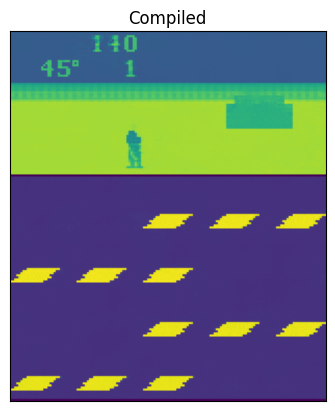

In [90]:
x = torch.sigmoid(wmfr.pixel_logits[0,-1])
x = x.permute(1,2,0)
plt.imshow(x)
plt.title('Compiled')
plt.xticks([])
plt.yticks([]);

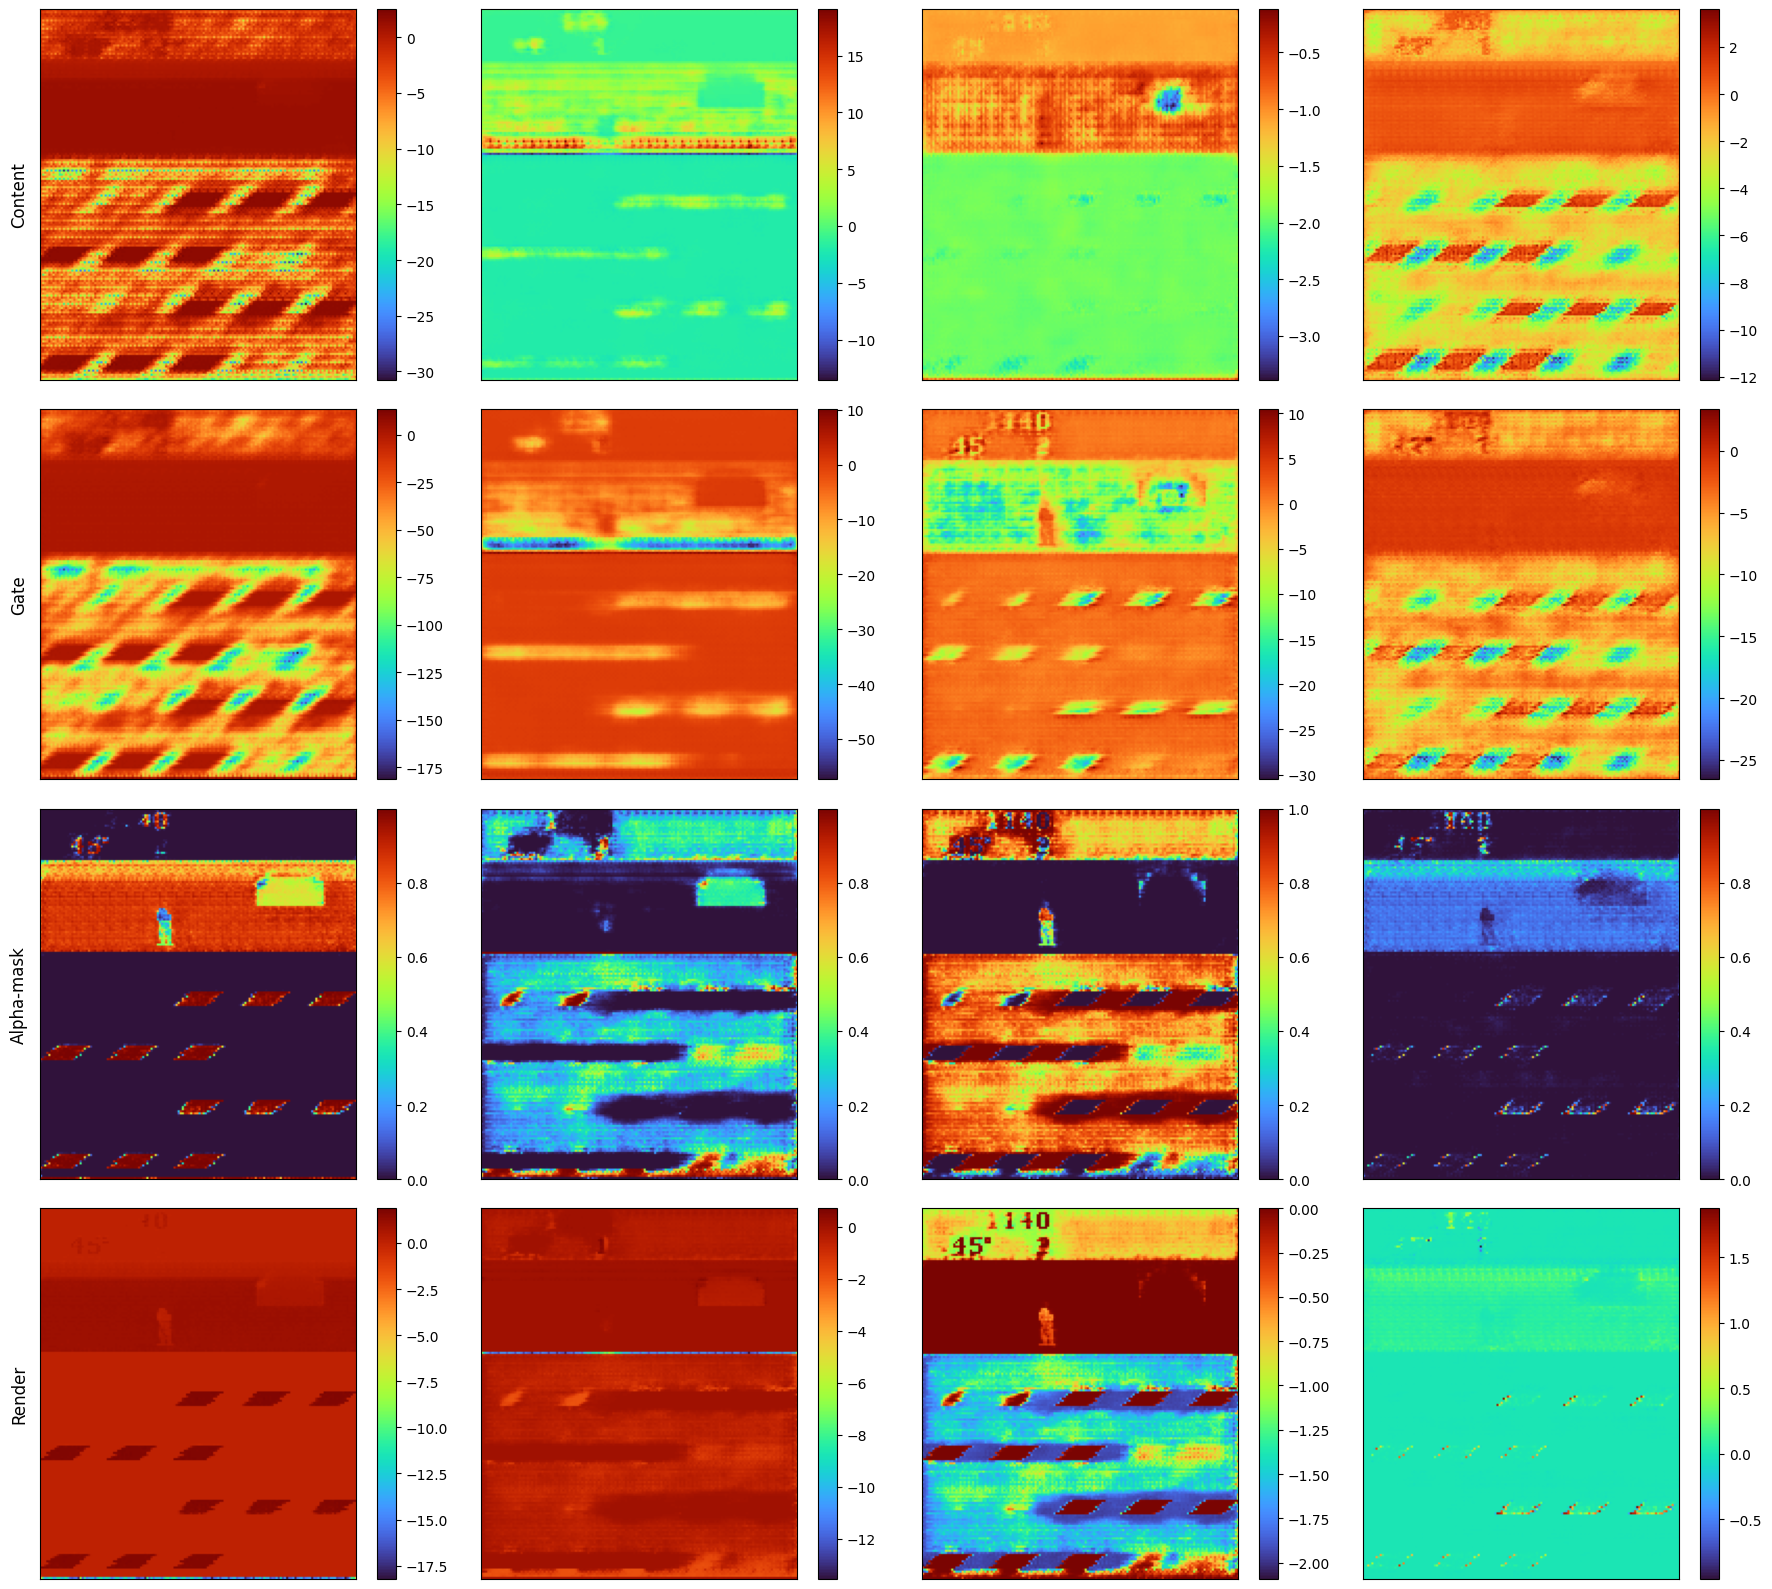

In [91]:
fig, axes = plt.subplots(4, 4)
fig.set_figwidth(18)
fig.set_figheight(4 * len(axes))

for i in range(len(axes)):
    for j in range(4):
        label = ''
        
        if i == 0:
            x = wmfr.pixel_contents[0,-1,j]
            # x = torch.sigmoid(x)
            label = 'Content'
        elif i == 1:
            x = wmfr.pixel_gates[0,-1,j]
            label = 'Gate'
        elif i == 2:
            x = wmfr.pixel_alpha_masks[0,-1,j]
            label = 'Alpha-mask'
        elif i == 3:
            content = wmfr.pixel_contents[0,-1,j]
            alpha_mask = wmfr.pixel_alpha_masks[0,-1,j]
            x = alpha_mask * content
            label = 'Render'

        x = x.permute(1,2,0)
        ax = axes[i,j]
        im = ax.imshow(x, cmap='turbo')
        fig.colorbar(im, ax=ax)

        axes[i,j].set_xticks([])
        axes[i,j].set_yticks([])

        if j == 0:
            axes[i,j].set_ylabel(label, rotation=90, size=12, labelpad=15, verticalalignment='center')

fig.tight_layout()

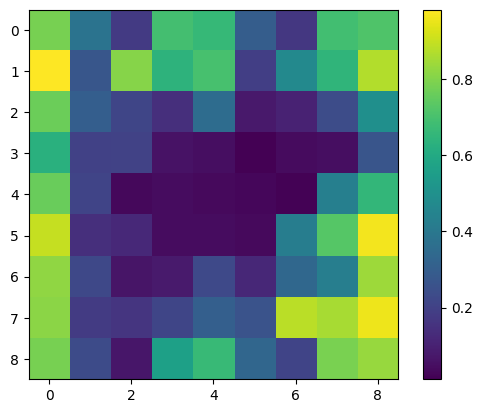

In [79]:
x = wmfr.pixel_alpha_masks[0,-1,0]
x = x.squeeze(0)
x = x[150:159,50:59]
plt.imshow(x)
plt.colorbar()

In [68]:
np.round(x.numpy(), 1)

array([[0.8, 0.4, 0.2, 0.7, 0.7, 0.3, 0.2, 0.7, 0.7],
       [1. , 0.3, 0.8, 0.6, 0.7, 0.2, 0.5, 0.6, 0.9],
       [0.8, 0.3, 0.2, 0.1, 0.4, 0.1, 0.1, 0.2, 0.5],
       [0.6, 0.2, 0.2, 0.1, 0. , 0. , 0. , 0. , 0.3],
       [0.8, 0.2, 0. , 0. , 0. , 0. , 0. , 0.4, 0.7],
       [0.9, 0.1, 0.1, 0. , 0. , 0. , 0.4, 0.7, 1. ],
       [0.8, 0.2, 0.1, 0.1, 0.2, 0.1, 0.3, 0.4, 0.8],
       [0.8, 0.2, 0.2, 0.2, 0.3, 0.3, 0.9, 0.9, 1. ],
       [0.8, 0.2, 0.1, 0.6, 0.7, 0.3, 0.2, 0.8, 0.8]], dtype=float32)

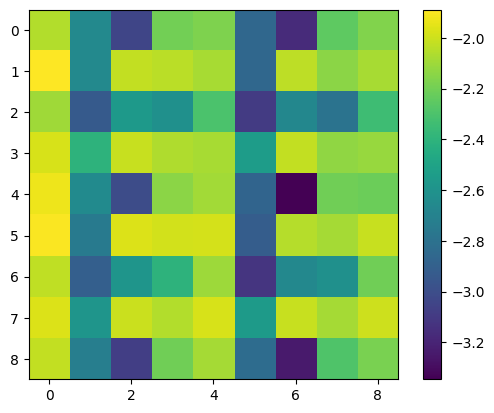

In [80]:
y = wmfr.pixel_contents[0,-1,0]
y = y.squeeze(0)
y = y[150:159,50:59]
plt.imshow(y)
plt.colorbar();

In [81]:
np.round(y.numpy(), 1)

array([[-2.1, -2.7, -3. , -2.2, -2.2, -2.9, -3.2, -2.3, -2.2],
       [-1.9, -2.7, -2. , -2. , -2.1, -2.9, -2. , -2.1, -2.1],
       [-2.1, -2.9, -2.6, -2.6, -2.3, -3.1, -2.7, -2.8, -2.3],
       [-2. , -2.4, -2. , -2.1, -2.1, -2.5, -2. , -2.1, -2.1],
       [-1.9, -2.6, -3. , -2.1, -2.1, -2.9, -3.3, -2.2, -2.2],
       [-1.9, -2.7, -2. , -2. , -2. , -2.9, -2.1, -2.1, -2. ],
       [-2. , -2.9, -2.6, -2.4, -2.1, -3.1, -2.7, -2.6, -2.2],
       [-2. , -2.6, -2. , -2.1, -2. , -2.6, -2. , -2.1, -2. ],
       [-2. , -2.7, -3.1, -2.2, -2.1, -2.8, -3.2, -2.3, -2.2]],
      dtype=float32)

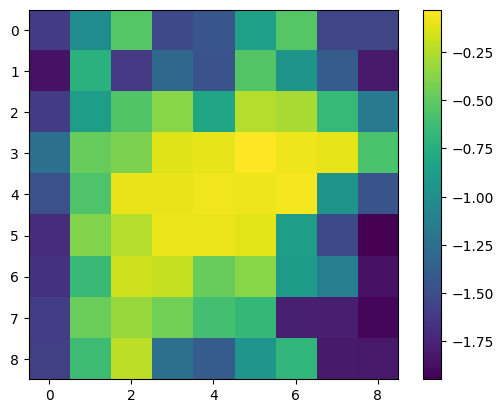

In [82]:
plt.imshow(x * y)
plt.colorbar();

In [73]:
np.round((x * y).numpy(), 1)

array([[-1.6, -1. , -0.5, -1.5, -1.4, -0.8, -0.5, -1.5, -1.5],
       [-1.9, -0.7, -1.6, -1.3, -1.5, -0.5, -1. , -1.4, -1.8],
       [-1.6, -0.9, -0.5, -0.4, -0.8, -0.2, -0.3, -0.7, -1.2],
       [-1.2, -0.5, -0.4, -0.1, -0.1, -0. , -0.1, -0.1, -0.6],
       [-1.5, -0.6, -0.1, -0.1, -0.1, -0.1, -0.1, -1. , -1.5],
       [-1.7, -0.4, -0.2, -0.1, -0.1, -0.1, -0.9, -1.5, -1.9],
       [-1.7, -0.6, -0.2, -0.2, -0.5, -0.4, -0.9, -1.1, -1.9],
       [-1.6, -0.5, -0.3, -0.4, -0.6, -0.7, -1.8, -1.8, -1.9],
       [-1.6, -0.6, -0.2, -1.2, -1.4, -0.9, -0.7, -1.8, -1.8]],
      dtype=float32)

In [77]:
torch.sigmoid(torch.tensor([-3, -1, -0.5, 0, 0.5, 1, 3]))

tensor([0.0474, 0.2689, 0.3775, 0.5000, 0.6225, 0.7311, 0.9526])